# V768 - Measuring Vision with Psychophysics

## Lab 11 - Ideal Observer Models

In earlier labs, you measured human performance on visual tasks. But how do we know if humans are performing well, and against what benchmark should we compare the results?

An **ideal observer** performs a task as well as is statistically possible given the information in the stimulus. Comparing human and ideal performance quantifies information lost during visual processing. This measure is called *efficiency*.

In this lab, you will build an ideal observer for contrast detection, simulate its performance with matched-filter detection theory, measure your own performance in the same task, and compute perceptual efficiency.

### Learning Outcomes

1. Define an ideal observer and explain why it is a useful benchmark.
2. Implement a matched-filter detector for a 2AFC contrast detection task.
3. Simulate trials and construct a psychometric curve.
4. Verify the relationship between signal energy, noise variance, and ideal *d′*.
5. Compute human efficiency relative to the ideal observer.

### Questions

1. Does the simulation match the analytical prediction? What could explain discrepancies?
2. What happens if you double the noise SD or the Gabor spatial frequency?
3. What is your measured efficiency, and how does it compare to typical values (10–50%)?
4. Would efficiency change near the visual resolution limit? Why?

## Background: ideal observers, matched filtering, and efficiency

An ideal observer has perfect task knowledge, uses all available stimulus information, and makes optimal inferences. Human performance is normally lower because of limits such as optical blur, photon or neural noise, inefficient coding, and limited attention.

This is a two-alternative forced-choice (2AFC) contrast detection task: both intervals contain independent white Gaussian noise, and one interval also contains a small Gabor patch. Chance performance is 50% correct.

The optimal strategy is a **matched filter**: calculate the dot product between each interval and the signal template $S$, then choose the interval with the larger response:

$$r_i = \sum\sum \mathrm{image}_i \times S.$$

For template energy $E=\sum S^2$, the ideal sensitivity and percent correct are

$$d'_{\mathrm{ideal}} = \frac{c\sqrt{E}}{\sigma_{\mathrm{noise}}}, \qquad \mathrm{PC}=\Phi\left(\frac{d'}{\sqrt{2}}\right).$$

Efficiency is the squared threshold ratio at a common criterion:

$$\eta = \left(\frac{d'_{\mathrm{human}}}{d'_{\mathrm{ideal}}}\right)^2 = \left(\frac{c_{\mathrm{ideal}}}{c_{\mathrm{human}}}\right)^2.$$

In [14]:
# Import file, probability, numerical, table, and plotting utilities.
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use SciPy for curve fitting when it is available.
try:
    from scipy.optimize import minimize
except ImportError:
    minimize = None


# Evaluate the normal cumulative distribution without requiring SciPy.
def normcdf(x, mu=0, sigma=1):
    x = np.asarray(x, dtype=float)
    dist = NormalDist(float(mu), max(float(sigma), np.finfo(float).eps))
    return np.vectorize(dist.cdf, otypes=[float])(x)


# Convert probabilities to normal-distribution quantiles.
def norminv(p, mu=0, sigma=1):
    p = np.clip(np.asarray(p, dtype=float), np.finfo(float).eps, 1 - np.finfo(float).eps)
    dist = NormalDist(float(mu), max(float(sigma), np.finfo(float).eps))
    return np.vectorize(dist.inv_cdf, otypes=[float])(p)


# Define the cumulative-Gaussian psychometric function used in this lab.
def cumulative_normal(contrast, threshold, slope):
    return normcdf((np.asarray(contrast, dtype=float) - threshold) / max(float(slope), np.finfo(float).eps))


# Fit threshold and slope by minimizing squared prediction error.
def fit_cumulative_normal(contrast, percent_correct):
    contrast = np.asarray(contrast, dtype=float)
    proportion = np.asarray(percent_correct, dtype=float) / 100
    def loss(params):
        threshold, log_slope = params
        return np.sum((proportion - cumulative_normal(contrast, threshold, np.exp(log_slope))) ** 2)
    # Prefer Nelder-Mead optimization; use a small grid search as a fallback.
    if minimize is not None:
        fitted = minimize(loss, [0.02, np.log(0.05)], method="Nelder-Mead").x
        return float(fitted[0]), float(np.exp(fitted[1]))
    threshold, log_slope = 0.02, np.log(0.05)
    for threshold_step, log_slope_step in [(0.05, 1), (0.01, 0.2), (0.002, 0.04), (0.0004, 0.008)]:
        candidates = [(threshold + dt, log_slope + ds) for dt in (-threshold_step, 0, threshold_step)
                      for ds in (-log_slope_step, 0, log_slope_step)]
        threshold, log_slope = min(candidates, key=loss)
    return float(threshold), float(np.exp(log_slope))


# Find every human-data CSV associated with a participant ID.
def find_participant_files(data_dir, participant_id):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise FileNotFoundError("PsychoPy data folder not found. Try changing your current Python folder to the folder containing this notebook.")
    paths = sorted(path for path in data_dir.glob(f"{participant_id}*.csv") if path.name.startswith(participant_id))
    if not paths:
        raise FileNotFoundError("No files found.")
    print("data files found:")
    for path in paths: print(f'    "{path.name}"')
    return paths

---

# Part 1. Building the stimulus

## 1.1 Create the signal template

Generate a vertical Gabor patch: a sinusoidal grating windowed by a Gaussian envelope. It will serve as the signal template $S$.

In [15]:
# Set the Gabor and noise-image parameters.
img_size = 64       # pixels
spatial_freq = 4    # cycles per image
orientation = 0     # degrees; 0 = vertical grating
gabor_sigma = 10    # Gaussian-envelope SD (pixels)
phase = 0           # radians
noise_sd = 0.2      # matches PsychoPy noise contrast

# Build a coordinate grid centered on the middle of the image.
x, y = np.meshgrid(np.arange(img_size), np.arange(img_size))
x = x - img_size / 2
y = y - img_size / 2
# Rotate the horizontal coordinate to support arbitrary Gabor orientations.
theta = np.deg2rad(orientation)
x_rot = x * np.cos(theta) - y * np.sin(theta)
# Create the sinusoidal carrier and Gaussian envelope.
wavelength = img_size / spatial_freq
grating = np.sin(2 * np.pi * x_rot / wavelength + phase)
gaussian_envelope = np.exp(-(x**2 + y**2) / (2 * gabor_sigma**2))

# Peak normalization makes contrast the Gabor's peak amplitude.
S = grating * gaussian_envelope
S = S / np.max(np.abs(S))
# Signal energy determines matched-filter sensitivity in Gaussian noise.
signal_energy = np.sum(S**2)

# Report the exact stimulus parameters used by later calculations.
print("Part 1: Building the stimulus")
print(f"  Image size: {img_size} × {img_size} pixels")
print(f"  Spatial frequency: {spatial_freq:.1f} cycles/image")
print(f"  Gabor sigma: {gabor_sigma:.1f} pixels")
print(f"  Signal energy (sum S²): {signal_energy:.4f}")
print(f"  Noise SD: {noise_sd:.2f}")

Part 1: Building the stimulus
  Image size: 64 × 64 pixels
  Spatial frequency: 4.0 cycles/image
  Gabor sigma: 10.0 pixels
  Signal energy (sum S²): 184.3328
  Noise SD: 0.20


## 1.2 Generate example stimulus pairs at different contrasts

The signal is a vertical grating. Can you see which interval contains it at low contrast? How does this change at high contrast?

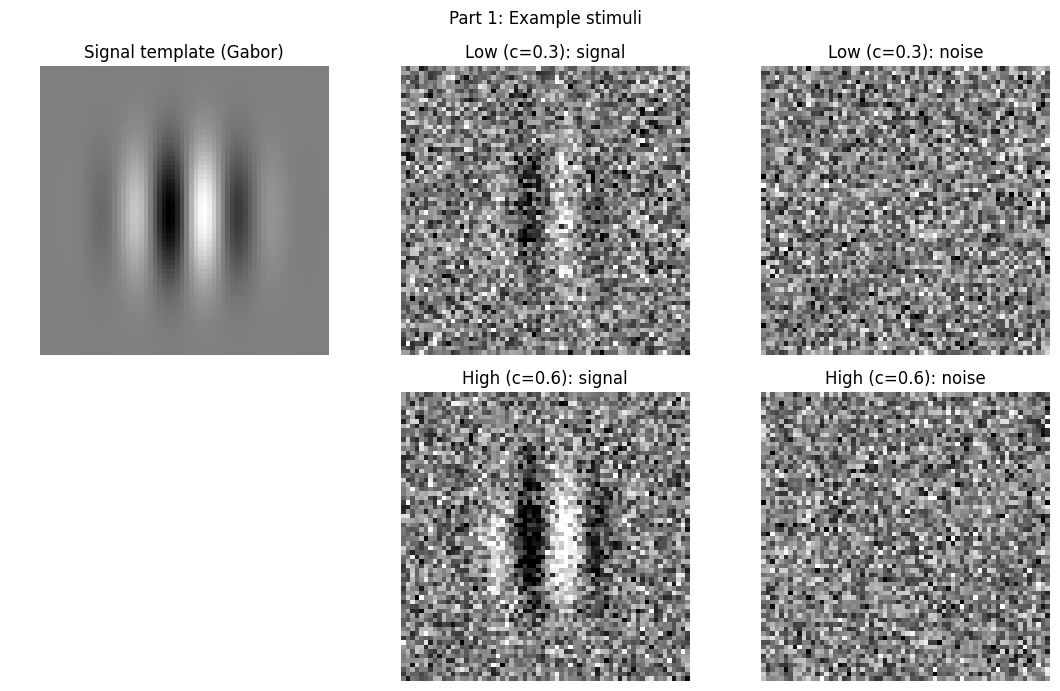

In [16]:
# Fix the random seed so the example images are reproducible.
rng = np.random.default_rng(42)
# Generate two independent noise images and add the Gabor to one interval.
def make_trial(contrast, signal_interval):
    noise_1 = noise_sd * rng.standard_normal((img_size, img_size))
    noise_2 = noise_sd * rng.standard_normal((img_size, img_size))
    stim_1 = 0.5 + noise_1 + (contrast * S if signal_interval == 1 else 0)
    stim_2 = 0.5 + noise_2 + (contrast * S if signal_interval == 2 else 0)
    return stim_1, stim_2

# Create one low-contrast and one high-contrast demonstration trial.
contrast_lo, contrast_hi = 0.3, 0.6
stim1_lo, stim2_lo = make_trial(contrast_lo, 1)
stim1_hi, stim2_hi = make_trial(contrast_hi, 1)
# Display the template alongside both stimulus intervals.
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
fig.suptitle("Part 1: Example stimuli")
images = [(S, "Signal template (Gabor)", -1, 1), (stim1_lo, f"Low (c={contrast_lo:.1f}): signal", 0, 1),
          (stim2_lo, f"Low (c={contrast_lo:.1f}): noise", 0, 1), (None, "", 0, 1),
          (stim1_hi, f"High (c={contrast_hi:.1f}): signal", 0, 1), (stim2_hi, f"High (c={contrast_hi:.1f}): noise", 0, 1)]
for ax, (image, title, vmin, vmax) in zip(axes.flat, images):
    if image is not None: ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_axis_off()
plt.tight_layout(); plt.show()

---

# Part 2. Simulating the ideal observer

The ideal observer computes the matched-filter response for each interval and selects the larger value. In Gaussian noise this is a sufficient statistic for the decision.

In [17]:
# Test the same seven contrast levels used by the PsychoPy experiment.
contrast_levels = np.array([0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 0.6])
# More trials reduce Monte Carlo sampling variability.
n_trials_per_contrast = 500
# Preallocate arrays that will store simulation results.
percent_correct = np.zeros(len(contrast_levels))
n_correct = np.zeros(len(contrast_levels), dtype=int)
# Summarize the planned simulation before it begins.
print("Part 2: Simulating the ideal observer")
print(f"  Number of contrast levels: {len(contrast_levels)}")
print(f"  Trials per level: {n_trials_per_contrast}")
print(f"  Total trials: {len(contrast_levels) * n_trials_per_contrast}")

Part 2: Simulating the ideal observer
  Number of contrast levels: 7
  Trials per level: 500
  Total trials: 3500


In [18]:
# Use a separate fixed seed for reproducible ideal-observer results.
rng = np.random.default_rng(123)
# Simulate an independent set of trials at each signal contrast.
for index, contrast in enumerate(contrast_levels):
    correct_count = 0
    for _ in range(n_trials_per_contrast):
        # Generate independent Gaussian noise for the two intervals.
        noise_1 = noise_sd * rng.standard_normal((img_size, img_size))
        noise_2 = noise_sd * rng.standard_normal((img_size, img_size))
        # Randomly place the Gabor in interval 1 or interval 2.
        signal_interval = rng.integers(1, 3)
        stim_1 = 0.5 + noise_1 + (contrast * S if signal_interval == 1 else 0)
        stim_2 = 0.5 + noise_2 + (contrast * S if signal_interval == 2 else 0)
        # The matched filter chooses the interval with the larger template response.
        choice = 2 if np.sum(stim_2 * S) > np.sum(stim_1 * S) else 1
        correct_count += choice == signal_interval
    n_correct[index] = correct_count
    # Convert the number correct to percent correct for this contrast.
    percent_correct[index] = 100 * correct_count / n_trials_per_contrast
    print(f"  Contrast c={contrast:.4f}: {correct_count}/{n_trials_per_contrast} correct ({percent_correct[index]:.1f}%)")
print("Simulation complete.")

  Contrast c=0.0001: 248/500 correct (49.6%)
  Contrast c=0.0010: 245/500 correct (49.0%)
  Contrast c=0.0100: 338/500 correct (67.6%)
  Contrast c=0.0300: 458/500 correct (91.6%)
  Contrast c=0.1000: 500/500 correct (100.0%)
  Contrast c=0.3000: 500/500 correct (100.0%)
  Contrast c=0.6000: 500/500 correct (100.0%)
Simulation complete.


## 2.3 Plot the psychometric curve

At zero contrast, performance should be at chance (50%). It should approach 100% as signal contrast increases.

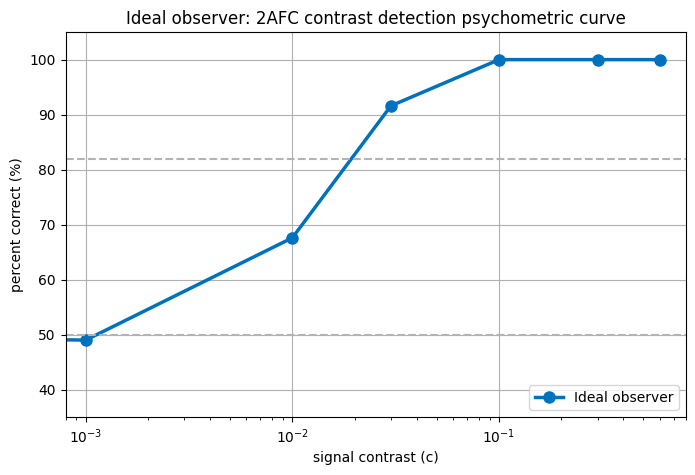

In [19]:
# Plot simulated percent correct as a function of contrast.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(contrast_levels, percent_correct, "o-", linewidth=2.5, markersize=8, color="#0072BD", label="Ideal observer")
# Mark chance performance and the conventional 82% threshold criterion.
ax.axhline(50, linestyle="--", color="0.7"); ax.axhline(82, linestyle="--", color="0.7")
# Use a logarithmic contrast axis to show low contrasts clearly.
ax.set(xscale="log", xlim=(0.0008, 0.8), ylim=(35, 105), xlabel="signal contrast (c)",
       ylabel="percent correct (%)", title="Ideal observer: 2AFC contrast detection psychometric curve")
ax.grid(True); ax.legend(loc="lower right"); plt.show()

---

# Part 3. Fitting and verification against theory

Fit the Live Script's cumulative-Gaussian psychometric model,

$$\mathrm{PC}=\Phi\left(\frac{c-c_{50}}{\mathrm{slope}}\right),$$

then compare its curve with the analytical matched-filter prediction.

In [20]:
# Fit a cumulative Gaussian to the simulated psychometric data.
threshold_fitted, slope_fitted = fit_cumulative_normal(contrast_levels, percent_correct)
# Invert the fitted curve to find the contrast yielding 82% correct.
threshold_82 = threshold_fitted + slope_fitted * norminv(0.82)
print("Fitted psychometric function:")
print(f"  Threshold (c50): {threshold_fitted:.4f}")
print(f"  Slope: {slope_fitted:.4f}")
print(f"  Threshold at 82% correct: {threshold_82:.4f}")

Fitted psychometric function:
  Threshold (c50): 0.0008
  Slope: 0.0208
  Threshold at 82% correct: 0.0199


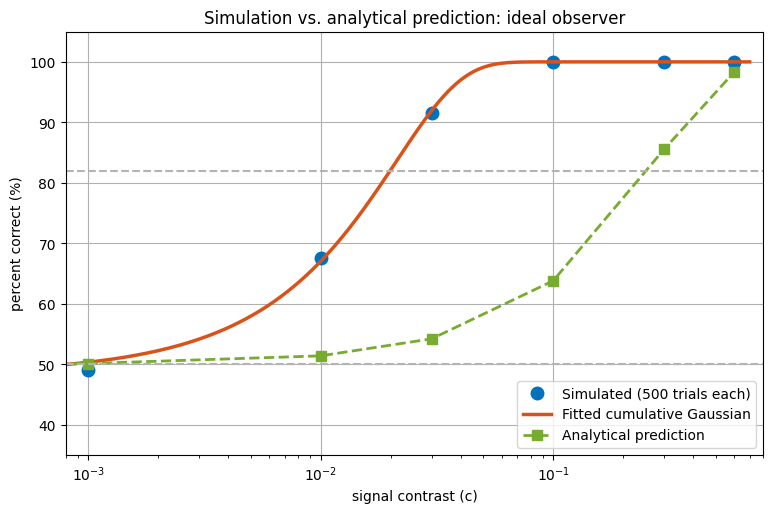

In [21]:
# Calculate ideal d′ from contrast, template energy, and external-noise SD.
d_prime_ideal = contrast_levels / noise_sd
pc_analytical = 100 * normcdf(d_prime_ideal / np.sqrt(2))

# Evaluate the fitted curve on a dense contrast grid for smooth plotting.
contrast_fine = np.logspace(np.log10(0.0005), np.log10(0.7), 200)
pc_fitted = 100 * cumulative_normal(contrast_fine, threshold_fitted, slope_fitted)

# Overlay simulated data, the fitted curve, and the analytical prediction.
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(contrast_levels, percent_correct, "o", markersize=9, color="#0072BD", label="Simulated (500 trials each)")
ax.plot(contrast_fine, pc_fitted, "-", linewidth=2.5, color="#D95319", label="Fitted cumulative Gaussian")
ax.plot(contrast_levels, pc_analytical, "s--", linewidth=2, markersize=7, color="#77AC30", label="Analytical prediction")
ax.axhline(50, linestyle="--", color="0.7"); ax.axhline(82, linestyle="--", color="0.7")
ax.set(xscale="log", xlim=(0.0008, 0.8), ylim=(35, 105), xlabel="signal contrast (c)",
       ylabel="percent correct (%)", title="Simulation vs. analytical prediction: ideal observer")
ax.grid(True); ax.legend(loc="lower right"); plt.show()

Finite simulation runs produce sampling variability. With fewer trials the simulated points scatter more; with more trials they move closer to the analytical prediction. Doubling the noise SD shifts the curve rightward. Increasing spatial frequency can reduce the signal energy (unless the window is adjusted), also making the task harder.

---

# Part 4. Measuring human performance

Run the contrast-detection PsychoPy task before this section. Enter the participant ID you used below; the default loads the included demo file.

In [22]:
# Replace "demo" with the participant ID used in the PsychoPy task.
participant_id = "demo"
# Find and combine every matching human-data CSV.
human_file_paths = find_participant_files(Path("contrast-detection") / "data", participant_id)
T = pd.concat([pd.read_csv(path) for path in human_file_paths], ignore_index=True)

# The nonzero interval contains the signal, so its value is the trial contrast.
contrast_vals = T[["contrast_1", "contrast_2"]].max(axis=1)
# Identify whether interval 1 or interval 2 contained the signal.
signal_interval = 1 + (T["contrast_2"] > T["contrast_1"]).astype(int)
response = pd.to_numeric(T["key_resp.keys"], errors="coerce")
correct = (response == signal_interval).astype(float)
# Exclude rows without a signal contrast or a recorded response.
valid = contrast_vals.notna() & contrast_vals.gt(0) & response.notna()
# Average correctness separately at each tested contrast level.
human_results = (
    pd.DataFrame({"contrast": contrast_vals[valid].astype(float), "correct": correct[valid]})
    .groupby("contrast", as_index=False)
    .agg(n_trials=("correct", "size"), percent_correct=("correct", lambda x: 100 * x.mean()))
)
human_contrast_levels = human_results["contrast"].to_numpy()
human_pc = human_results["percent_correct"].to_numpy()
# Inspect the number of trials and percent correct per contrast.
display(human_results)

data files found:
    "demo_contrast-detection_2026-04-23_02h55.16.676.csv"


,contrast,n_trials,percent_correct
0,0.0001,20,75.0
1,0.0010,20,40.0
2,0.0100,20,45.0
3,0.0300,20,75.0
4,0.1000,20,95.0
5,0.3000,20,100.0
6,0.6000,20,95.0


## 4.2 Fit a psychometric function

In [23]:
# Fit the same cumulative-Gaussian model to the human data.
threshold_human, slope_human = fit_cumulative_normal(human_contrast_levels, human_pc)
# Find the human contrast threshold at 82% correct.
threshold_82_human = threshold_human + slope_human * norminv(0.82)
print(f"  Fitted threshold (c50): {threshold_human:.4f}")
print(f"  Threshold at 82%: {threshold_82_human:.4f}")

  Fitted threshold (c50): -0.0044
  Threshold at 82%: 0.0555


## 4.3 Compute efficiency

Efficiency is the squared ratio of ideal to human threshold at the 82% criterion. Values from 10–50% are typical for simple detection.

In [24]:
# Efficiency is the squared ratio of ideal to human threshold.
eta = (threshold_82 / threshold_82_human) ** 2
print(f"  Efficiency: {100 * eta:.1f}%")

  Efficiency: 12.8%


## 4.4 Plot human vs. ideal

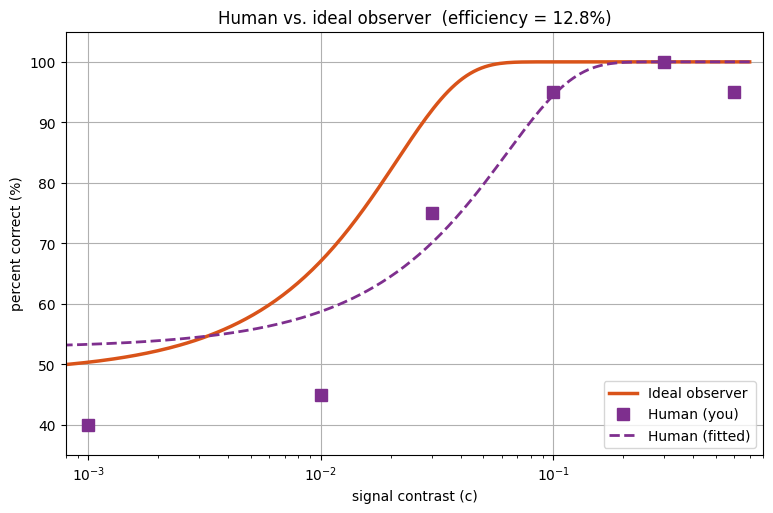

In [25]:
# Evaluate the fitted human curve on the same contrast grid as the ideal curve.
pc_human_fine = 100 * cumulative_normal(contrast_fine, threshold_human, slope_human)
# Compare ideal and human psychometric performance in one figure.
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(contrast_fine, pc_fitted, "-", linewidth=2.5, color="#D95319", label="Ideal observer")
ax.plot(human_contrast_levels, human_pc, "s", markersize=9, color="#7E2F8E", label="Human (you)")
ax.plot(contrast_fine, pc_human_fine, "--", linewidth=2, color="#7E2F8E", label="Human (fitted)")
ax.set(xscale="log", xlim=(0.0008, 0.8), ylim=(35, 105), xlabel="signal contrast (c)",
       ylabel="percent correct (%)", title=f"Human vs. ideal observer  (efficiency = {100 * eta:.1f}%)")
ax.grid(True); ax.legend(loc="lower right"); plt.show()

---

## Part 5. Extensions *(optional, for discussion)*

1. **Suboptimal observers:** use a mismatched Gabor template and measure the cost of a 15° orientation error.
2. **Internal noise:** add Gaussian internal noise to the decision variable and find a level that reproduces human efficiency.
3. **Non-white noise:** use 1/f noise. Does the standard matched filter remain ideal, and what must change?

## Helper functions

In [26]:
# Convert percent correct to the appropriate signal-detection sensitivity measure.
def dprime_from_pc(pc, task_type):
    """Convert percent correct to d′ for a Yes/No or 2AFC task."""
    # Yes/No and 2AFC tasks use different d′ scaling factors.
    if task_type == "YesNo": return 2 * norminv(np.asarray(pc) / 100)
    if task_type == "2AFC": return np.sqrt(2) * norminv(np.asarray(pc) / 100)
    raise ValueError("Unknown task type. Use 'YesNo' or '2AFC'.")

# Compare human and ideal sensitivity directly at matched percent-correct values.
def compute_efficiency(pc_human, pc_ideal):
    """Compute perceptual efficiency from human and ideal percent correct."""
    return (dprime_from_pc(pc_human, "2AFC") / dprime_from_pc(pc_ideal, "2AFC")) ** 2